This script will contain the chromatin tracing analysis for the primary GBM sample. 

The chromatin tracing has been run with `ecDNATracer` with default parameters. Unlike the ecDNA in GBM39, our probes only covered partially of the areas. Because of this, we did not enforce the circular assumption in tracing the ecDNA.

We will also focus on `AC/MES like GBM cells`.

Relevant figures can be found in Figure 6, Extended Data Figure 19, 20.

In [1]:
import numpy as np
import os
import pandas as pd

In [21]:
import sys
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_HelperFunctions import *
from plot import *

# chromatin tracing: basic analysis

## load traces

In [2]:
import pickle
with open('D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___Human_P4CC_EGFR_12_17_2024\human_allcellspossible__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)

In [3]:
tr_type = 'Xtraces_chrom_inter_148_149_151'

In [7]:
linear_traces, circ_traces_all = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces_all.shape

((4314, 252, 6), (319079, 252, 6))

In [9]:
## subset to only cells that have endougenous chr7 identified
ufovcells= np.unique(np.nanmean(linear_traces[:,:, -1], axis = 1))
len(ufovcells)

3955

In [10]:
circ_traces = circ_traces_all[np.isin(np.nanmean(circ_traces_all[:,:, -1], axis = 1), ufovcells)]
circ_traces.shape

(31853, 252, 6)

In [11]:
del circ_traces_all

## subset to only cluster of interest

AC/MES like GBM cells are leiden cluster 4 and 5

In [23]:
istart = 3
iend = 125

In [31]:
start_mb = 54.9
end_mb = 55.5

In [13]:
df_meta = pd.read_csv(r'C:/GBM39/Human_P4CC_EGFR_12_17_2024/20251027_dcc3_cell_metadata_subset.csv')

In [14]:
df_meta['ifovcell'] = df_meta['cell_name'].apply(lambda x: int(x.split('_')[-1]))

In [15]:
ufovcells_all= np.unique(np.nanmean(linear_traces[:,:, -1], axis = 1))

df_cluster_big = df_meta[df_meta['ifovcell'].isin(ufovcells_all)]
df_cluster_big.shape

(3548, 7)

In [16]:
dic_ifovcell_leiden = dict(zip(df_cluster_big['ifovcell'], df_cluster_big['leiden']))
dic_leiden_ifovcell = {}
for cell in dic_ifovcell_leiden:
    leiden = dic_ifovcell_leiden[cell]
    if leiden in dic_leiden_ifovcell.keys():
        dic_leiden_ifovcell[leiden].append(cell)
    else:
        dic_leiden_ifovcell[leiden] = [cell]

In [27]:
acmes_linear_traces = linear_traces[np.isin(np.nanmean(linear_traces[:,:, -1], axis = 1),dic_leiden_ifovcell[4] + dic_leiden_ifovcell[5])]
acmes_circ_traces = circ_traces[np.isin(np.nanmean(circ_traces[:,:, -1], axis = 1),dic_leiden_ifovcell[4]+ dic_leiden_ifovcell[5])]
len(acmes_linear_traces), len(acmes_circ_traces)

(1311, 14484)

# comparison to HiC

In [28]:
acmes_joint_traces = np.vstack([acmes_linear_traces, acmes_circ_traces])
acmes_joint_traces.shape

(15795, 252, 6)

In [29]:
acmes_joint_meddist = np.nanmedian(compute_med_dist_mat(acmes_joint_traces[:, istart:iend+1, :], contact_dist = None), axis = 0)
acmes_joint_meddist.shape

100%|█████████████████████████████████████████████████████████████████████████| 15795/15795 [00:01<00:00, 12549.08it/s]


(123, 123)

## plot joint matrix

Text(0.5, 1.0, 'AC/MES like GBM Median distance\n 1143 cells, 15795 traces')

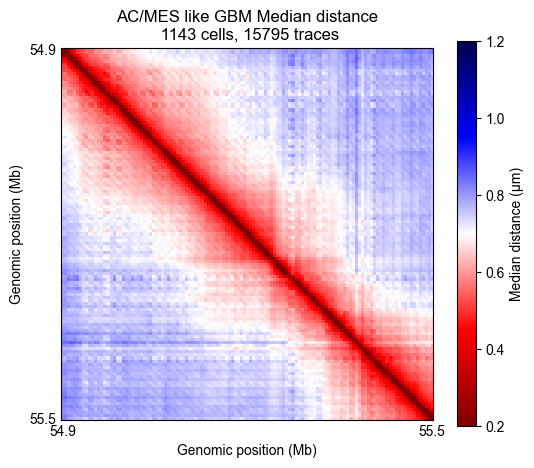

In [32]:
ntrs = len(acmes_joint_traces)
ncells = len(np.unique(np.nanmean(acmes_joint_traces[:,:,-1], axis = 1)))
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard

plt.rcParams['font.family'] = 'Arial'

# --- Data & colormap with NaNs as dark gray ---
M0 = acmes_joint_meddist.copy()
M0_smooth = cv2.blur(M0, (2, 2))

cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
import numpy as np
import matplotlib.pyplot as plt

N = M0_smooth.shape[0]
labels = np.arange(istart, iend + 1)          # length should be N
tick_step = 10                                 # change to taste
ticks = np.arange(0, N, tick_step)

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
im = ax.imshow(M0_smooth, cmap=cmap, vmin=0.2, vmax=1.2,
               interpolation='nearest', rasterized=True)

# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (µm)')
ax.set_title(f'AC/MES like GBM Median distance\n {ncells} cells, {ntrs} traces')


# --- Save (rasterized artists embedded at 1200 dpi) ---

## droplet HiC

In [33]:
hic_mat = np.load(r'D:\GBM39\P4CC_HiC\LC649_merged_hg38_ecDNA_hic_balanced.npy')
hic_mat = hic_mat[istart:iend+1, istart:iend+1]
hic_mat.shape

(123, 123)

In [34]:
eps = 1e-6
L = np.log10(hic_mat + eps)
vmin = np.nanpercentile(L, 5)
vmax = np.nanpercentile(L, 99)
vmin,vmax

(-6.0, -1.5591398579270148)

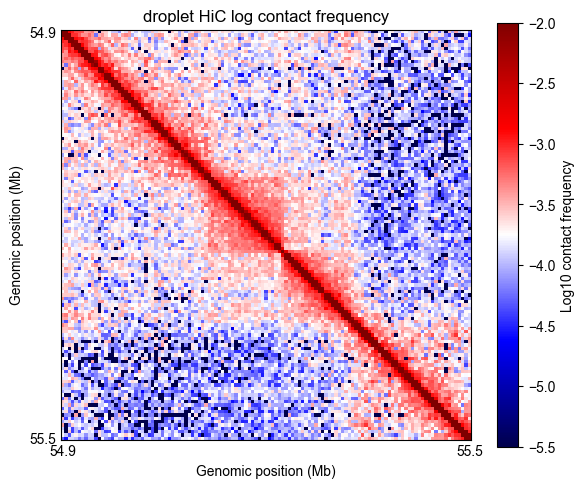

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard
plt.rcParams['font.family'] = 'Arial'



# --- Data & colormap with NaNs as dark gray ---
M0 = L.copy()
cmap = plt.cm.seismic.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=-2, vmax=-5,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Log10 contact frequency')
ax.set_title(f'droplet HiC log contact frequency')

fig.tight_layout()

# --- Save (rasterized artists embedded at 1200 dpi) ---

## plot correlation: HiC vs. FISH

In [36]:
D_circ_contact = compute_med_dist_mat(acmes_joint_traces[:, istart:iend+1, :], contact_dist = None)
D_circ_contact.shape

100%|█████████████████████████████████████████████████████████████████████████| 15795/15795 [00:01<00:00, 12020.66it/s]


(15795, 123, 123)

In [37]:
D_circ_contact_freq =  np.mean(D_circ_contact < 0.25, axis=0)/ np.mean(D_circ_contact >= 0., axis=0)
D_circ_contact_freq.shape

(123, 123)

In [38]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import pearsonr

def plot_hic_vs_spatial_log10(
    hic_mat: np.ndarray,
    spatial_mat: np.ndarray,
    vmax_dist: int = 120,
    plot_type: str = 'dist',              # 'dist' or anything else -> label tweak
    log: bool = True,                     # log10 axes (actually plotting log10 values)
    s: float = 5,                         # dot size
    alpha: float = 0.8,                   # dot alpha
    cmap: str = 'coolwarm',               # colormap for genomic distance
    svg_path = None,          # e.g., r"C:\path\plot.svg"
    dots_dpi: int = 300,                  # resolution for the rasterized dots
    clip_frac = (0, 1),                   # optional percentile clip on values (0..1, no clip)
    title = None
):
    """
    Scatter Hi-C vs spatial (upper triangle), color-coded by genomic distance.
    If log=True, plots log10(hic) vs log10(spatial) on linear axes and
    computes Pearson r in log10 space.

    Returns
    -------
    fig, ax, pearson_r
    """
    assert hic_mat.shape == spatial_mat.shape, "Hi-C and spatial matrices must have same shape"
    N = hic_mat.shape[0]

    # --- Upper triangle (exclude diagonal) ---
    iu, ju = np.triu_indices(N, k=1)
    hic_vals = hic_mat[iu, ju].astype(float)
    spatial_vals = spatial_mat[iu, ju].astype(float)
    genomic_dists = np.abs(iu - ju)

    # --- Optional percentile clipping on values (helps with extreme outliers) ---
    if clip_frac != (0, 1):
        lo_hic, hi_hic = np.nanpercentile(hic_vals, [100*clip_frac[0], 100*clip_frac[1]])
        lo_spa, hi_spa = np.nanpercentile(spatial_vals, [100*clip_frac[0], 100*clip_frac[1]])
        hic_vals = np.clip(hic_vals, lo_hic, hi_hic)
        spatial_vals = np.clip(spatial_vals, lo_spa, hi_spa)

    # --- Valid mask (and >0 if using log10) ---
    if log:
        valid = (
            np.isfinite(hic_vals) &
            np.isfinite(spatial_vals) &
            (hic_vals > 0) &
            (spatial_vals > 0)
        )
    else:
        valid = np.isfinite(hic_vals) & np.isfinite(spatial_vals)

    hic_vals = hic_vals[valid]
    spatial_vals = spatial_vals[valid]
    genomic_dists = genomic_dists[valid]

    # --- Transform for plotting + Pearson ---
    if log:
        x_plot = np.log10(hic_vals)
        y_plot = np.log10(spatial_vals)
        if len(x_plot) > 1:
            pearson_r, pearson_pval = pearsonr(x_plot, y_plot)
        else:
            pearson_r = np.nan
            pearson_pval = np.nan
    else:
        x_plot = hic_vals
        y_plot = spatial_vals
        if len(x_plot) > 1:
            pearson_r, pearson_pval = pearsonr(x_plot, y_plot)
        else:
            pearson_r = np.nan
            pearson_pval = np.nan

    print(f'pearson_pval = {pearson_pval}')
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6))
    norm = Normalize(0, vmax_dist)
    sc = ax.scatter(
        x_plot, y_plot,
        c=np.clip(genomic_dists, 0, vmax_dist),
        cmap=cmap, norm=norm,
        s=s, alpha=alpha
    )

    # Rasterize ONLY the scatter dots in the SVG
    sc.set_rasterized(True)

    # axis labels
    ylab = 'pairwise spatial distance (µm)' if plot_type == 'dist' \
           else 'contact freq (<250 nm)'

    if log:
        ax.set_xlabel('log10 Droplet Hi-C interaction frequency')
        ax.set_ylabel(f'log10 Multimodal MERFISH\n{ylab}')
        base_title = 'Hi-C vs Spatial (log10–log10)'
    else:
        ax.set_xlabel('Droplet Hi-C interaction frequency')
        ax.set_ylabel(f'Multimodal MERFISH\n{ylab}')
        base_title = 'Hi-C vs Spatial'

    ttl = title if title is not None else f'{base_title}\n Pearson r = {pearson_r:.3f}, p = {pearson_pval}'
    ax.set_title(ttl)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Genomic distance (bins)')

    plt.tight_layout()

    # --- Save SVG with editable text, vectors for everything except dots ---
    if svg_path is not None:
        prev_font = mpl.rcParams.get('font.family', None)
        prev_svg = mpl.rcParams.get('svg.fonttype', None)
        try:
            mpl.rcParams['font.family'] = 'Arial'
            mpl.rcParams['svg.fonttype'] = 'none'  # keep text as text
            plt.savefig(svg_path, format='svg', dpi=dots_dpi, bbox_inches='tight')
        finally:
            if prev_font is not None:
                mpl.rcParams['font.family'] = prev_font
            if prev_svg is not None:
                mpl.rcParams['svg.fonttype'] = prev_svg
        # plt.close(fig)
    else:
        plt.show()

    return fig, ax, pearson_r



pearson_pval = 0.0


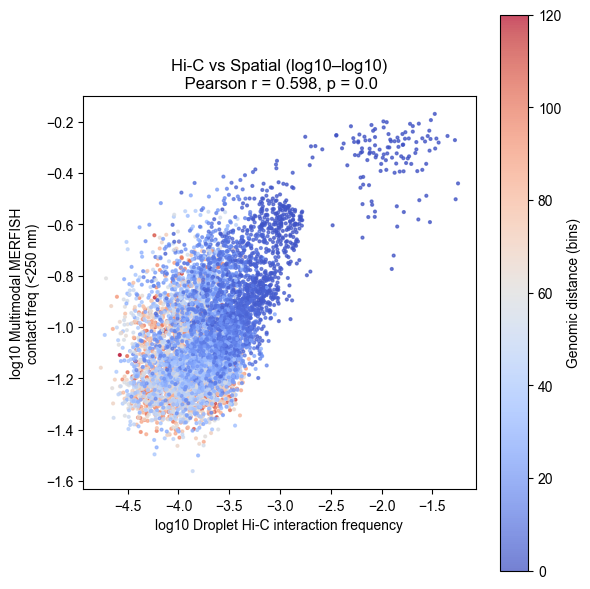

In [41]:
fig, ax, r = plot_hic_vs_spatial_log10(hic_mat = hic_mat, spatial_mat = D_circ_contact_freq, 
                    vmax_dist=120, plot_type = 'contact', log = True,
    # svg_path='C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/hic/humanP4CC_hic_vs_FISH_correlation.svg',
    dots_dpi=600, s=4, alpha=0.7)

# chr7 vs. ecDNA

## chr7 median distance matrix

In [42]:
acmes_linear_meddist = np.nanmedian(compute_med_dist_mat(acmes_linear_traces[:, istart:iend+1, :], contact_dist = None), axis = 0)
acmes_linear_meddist.shape

100%|███████████████████████████████████████████████████████████████████████████| 1311/1311 [00:00<00:00, 10562.85it/s]


(123, 123)

Text(0.5, 1.0, 'chr7 Median distance\n 1143 cells, 1311 traces')

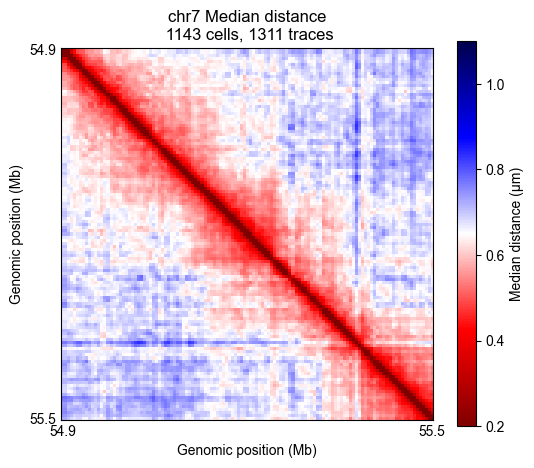

In [43]:
ntrs = len(acmes_linear_traces)
ncells = len(np.unique(np.nanmean(acmes_linear_traces[:,:,-1], axis = 1)))
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard

plt.rcParams['font.family'] = 'Arial'

# --- Data & colormap with NaNs as dark gray ---
M0 = acmes_linear_meddist.copy()
M0_smooth = cv2.blur(M0, (2, 2))

cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
import numpy as np
import matplotlib.pyplot as plt

N = M0_smooth.shape[0]
labels = np.arange(istart, iend + 1)          # length should be N
tick_step = 10                                 # change to taste
ticks = np.arange(0, N, tick_step)

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
im = ax.imshow(M0_smooth, cmap=cmap, vmin=0.2, vmax=1.1,
               interpolation='nearest', rasterized=True)


# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")


# ----------------
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (µm)')
ax.set_title(f'chr7 Median distance\n {ncells} cells, {ntrs} traces')


# --- Save (rasterized artists embedded at 1200 dpi) ---

## ecDNA median distance matrix

This is the one in the main figure

In [44]:
acmes_circ_meddist = np.nanmedian(compute_med_dist_mat(acmes_circ_traces[:, istart:iend+1, :], contact_dist = None), axis = 0)
acmes_circ_meddist.shape

100%|█████████████████████████████████████████████████████████████████████████| 14484/14484 [00:01<00:00, 13651.67it/s]


(123, 123)

Text(0.5, 1.0, 'ecDNA Median distance\n 1143 cells, 14484 traces')

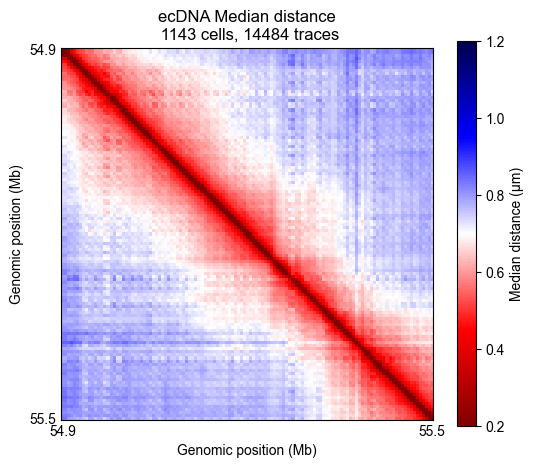

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt

ntrs = len(acmes_circ_traces)
ncells = len(np.unique(np.nanmean(acmes_circ_traces[:,:,-1], axis = 1)))

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard

plt.rcParams['font.family'] = 'Arial'

# --- Data & colormap with NaNs as dark gray ---
M0 = acmes_circ_meddist.copy()
M0_smooth = cv2.blur(M0, (2, 2))

cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
import numpy as np
import matplotlib.pyplot as plt

N = M0_smooth.shape[0]
labels = np.arange(istart, iend + 1)          # length should be N
tick_step = 10                                 # change to taste
ticks = np.arange(0, N, tick_step)

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
im = ax.imshow(M0_smooth, cmap=cmap, vmin=0.2, vmax=1.2,
               interpolation='nearest', rasterized=True)

# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (µm)')
ax.set_title(f'ecDNA Median distance\n {ncells} cells, {ntrs} traces')

## difference

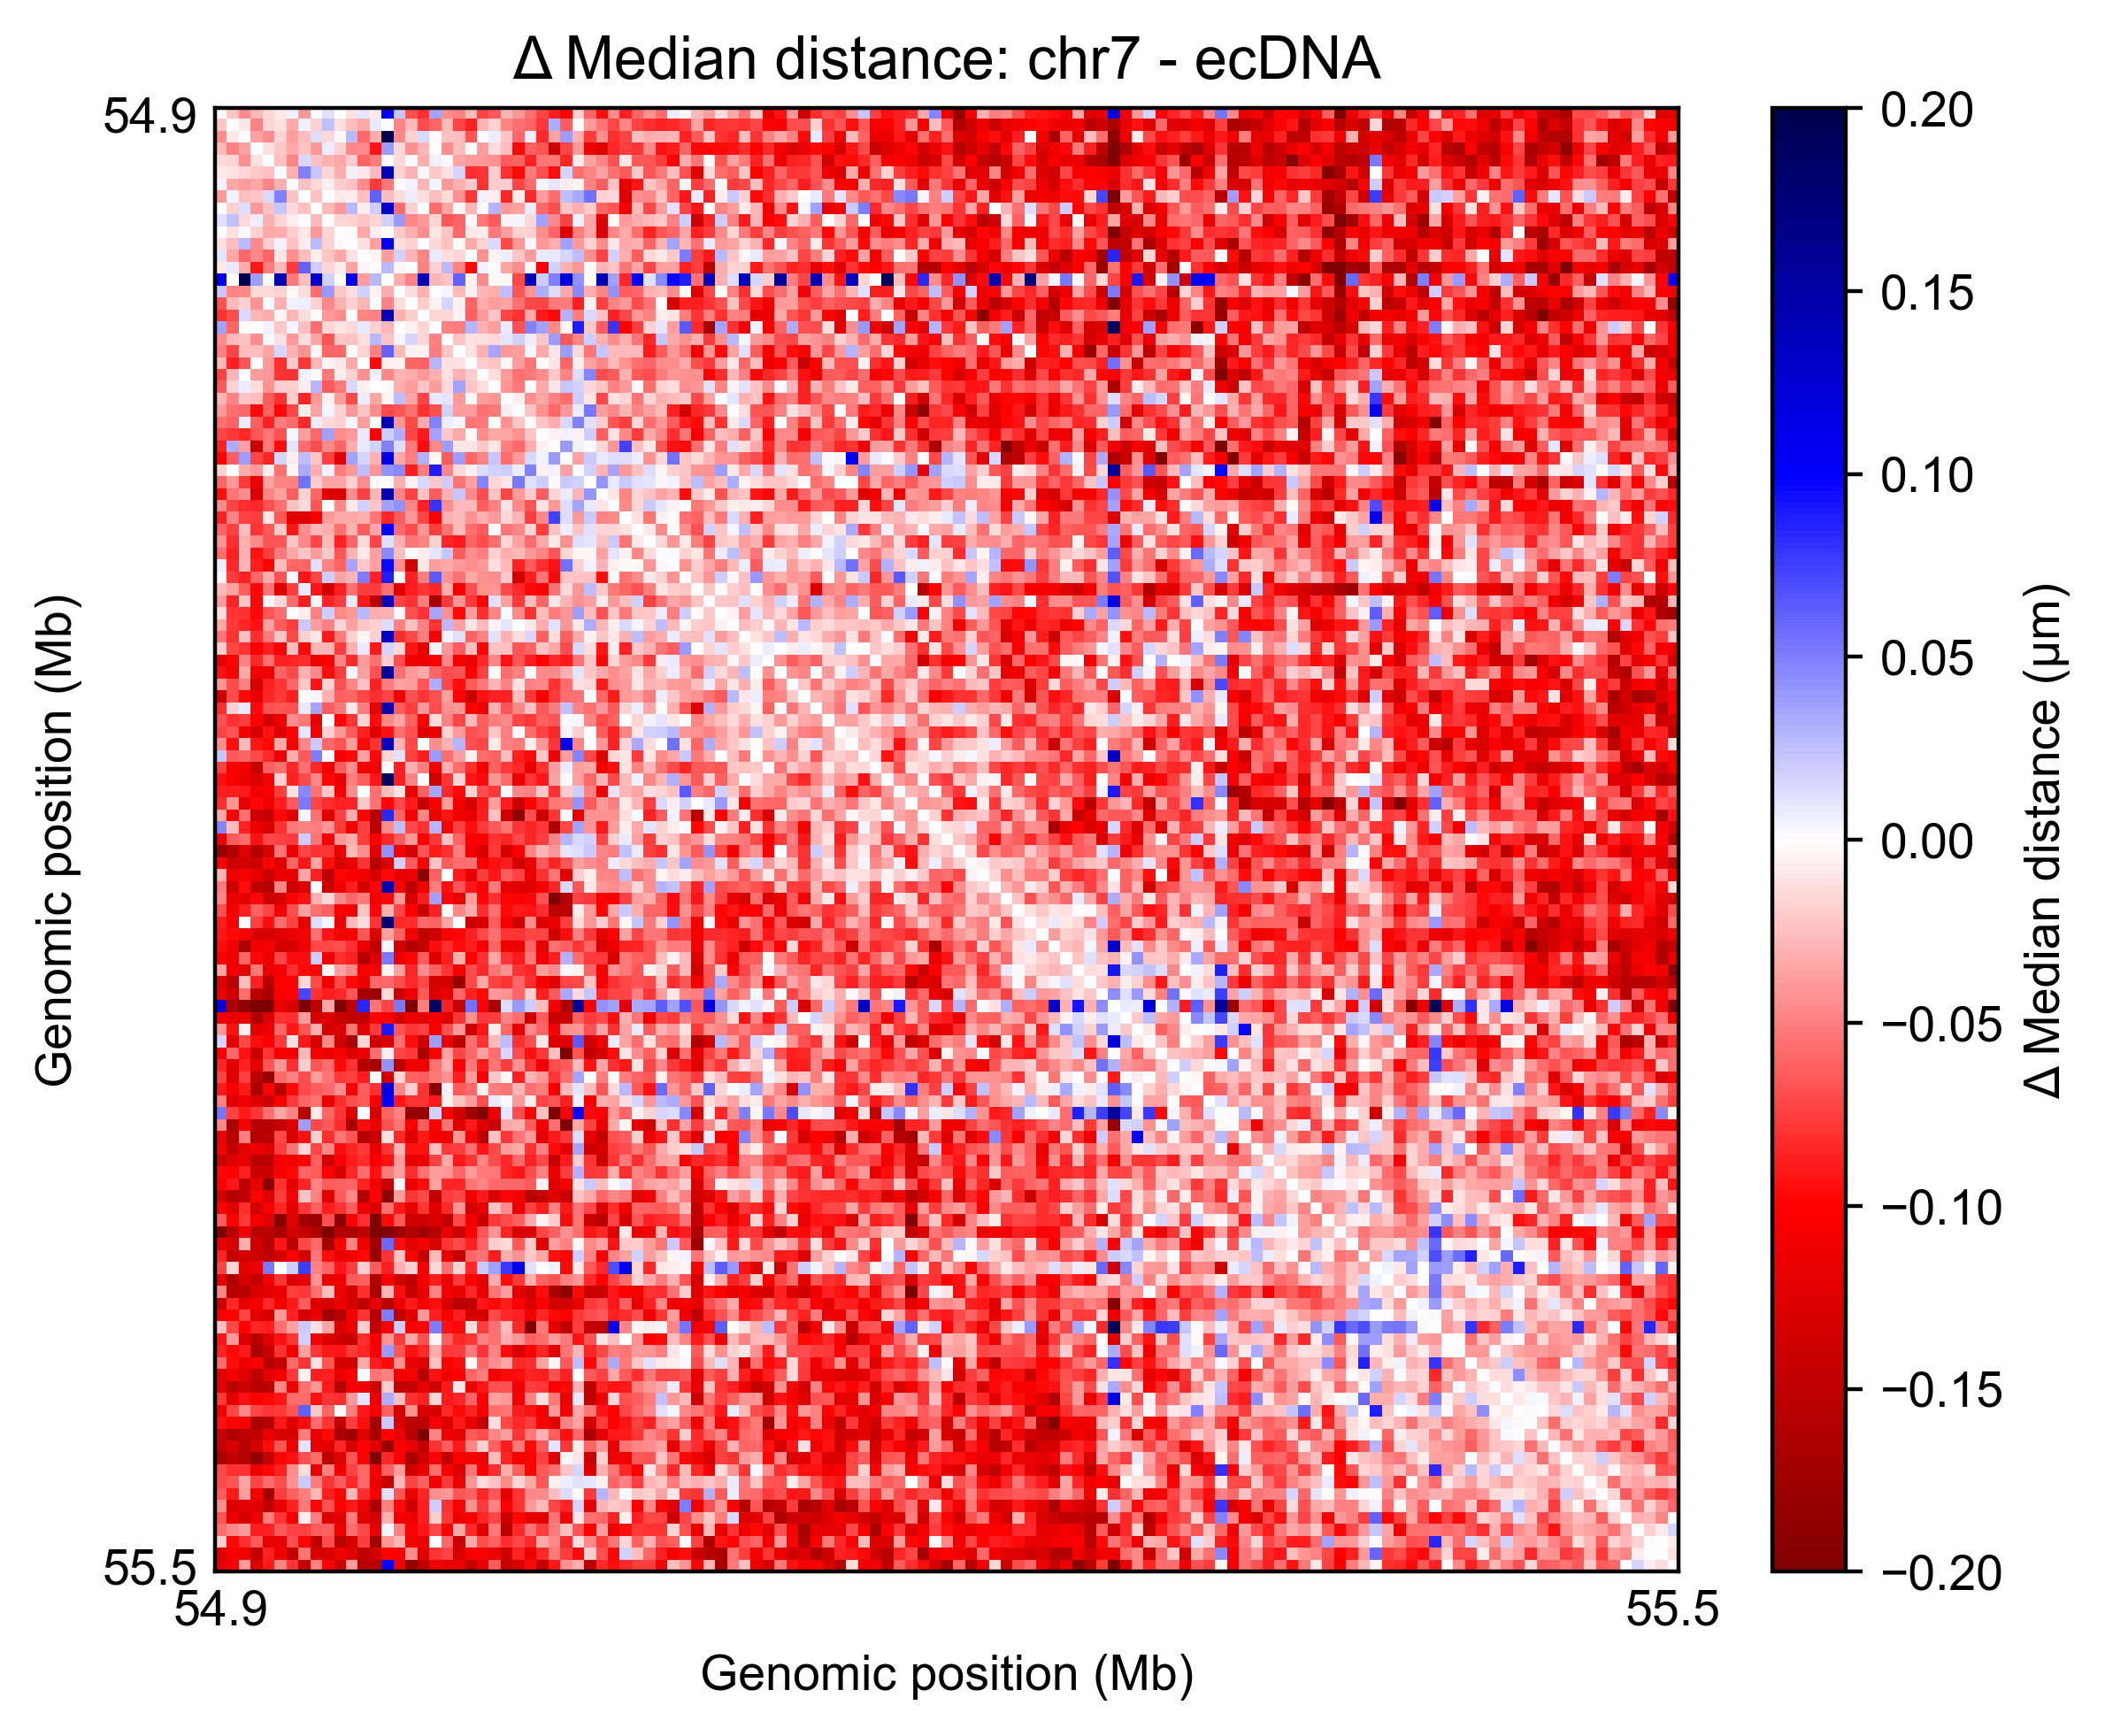

In [46]:
# --- Data & colormap with NaNs as dark gray ---
Mdiff = acmes_linear_meddist - acmes_circ_meddist
M0 = cv2.blur(Mdiff, (2,2))
cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6.2, 5), dpi=400)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(Mdiff, cmap=cmap, vmin=-0.2, vmax=0.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Median distance (µm)')

ax.set_title(f'Δ Median distance: chr7 - ecDNA')

fig.tight_layout()


## radius of gyration

In [47]:
def get_rgs(coords_um):
    coords_um = np.array(coords_um)
    coords_um -= np.nanmean(coords_um, axis=0)[np.newaxis, :]  # center of mass
    distances = np.linalg.norm(coords_um, axis=-1)
    rg = np.sqrt(np.nanmean(distances ** 2))
    return rg

In [48]:
lin_all_rgs = [get_rgs(tr[:,:3]) for tr in acmes_linear_traces[:, istart:iend+1, :] ]
circ_all_rgs = [get_rgs(tr[:,:3]) for tr in acmes_circ_traces[:, istart:iend+1, :] ]

In [49]:
df_plot_violin = pd.DataFrame(lin_all_rgs+ circ_all_rgs, columns = ['rgs'])
df_plot_violin['is_circular'] = [0] * len(lin_all_rgs) + [1] * len(circ_all_rgs)
df_plot_violin

,rgs,is_circular
0,0.915168,0
1,0.489849,0
2,0.407898,0
3,0.511280,0
4,0.316534,0
...,...,...
15790,0.312484,1
15791,0.401901,1
15792,0.248548,1
15793,0.363758,1


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Radius of gyration:chr7 vs. ecDNA'}, ylabel='Radius of gyration (µm)'>,
             rgs  is_circular
 0      0.915168        False
 1      0.489849        False
 2      0.407898        False
 3      0.511280        False
 4      0.316534        False
 ...         ...          ...
 15790  0.312484         True
 15791  0.401901         True
 15792  0.248548         True
 15793  0.363758         True
 15794  0.415546         True
 
 [15795 rows x 2 columns],
 {'U': 7951373.5, 'p': 1.687913203296084e-22, 'q': None})

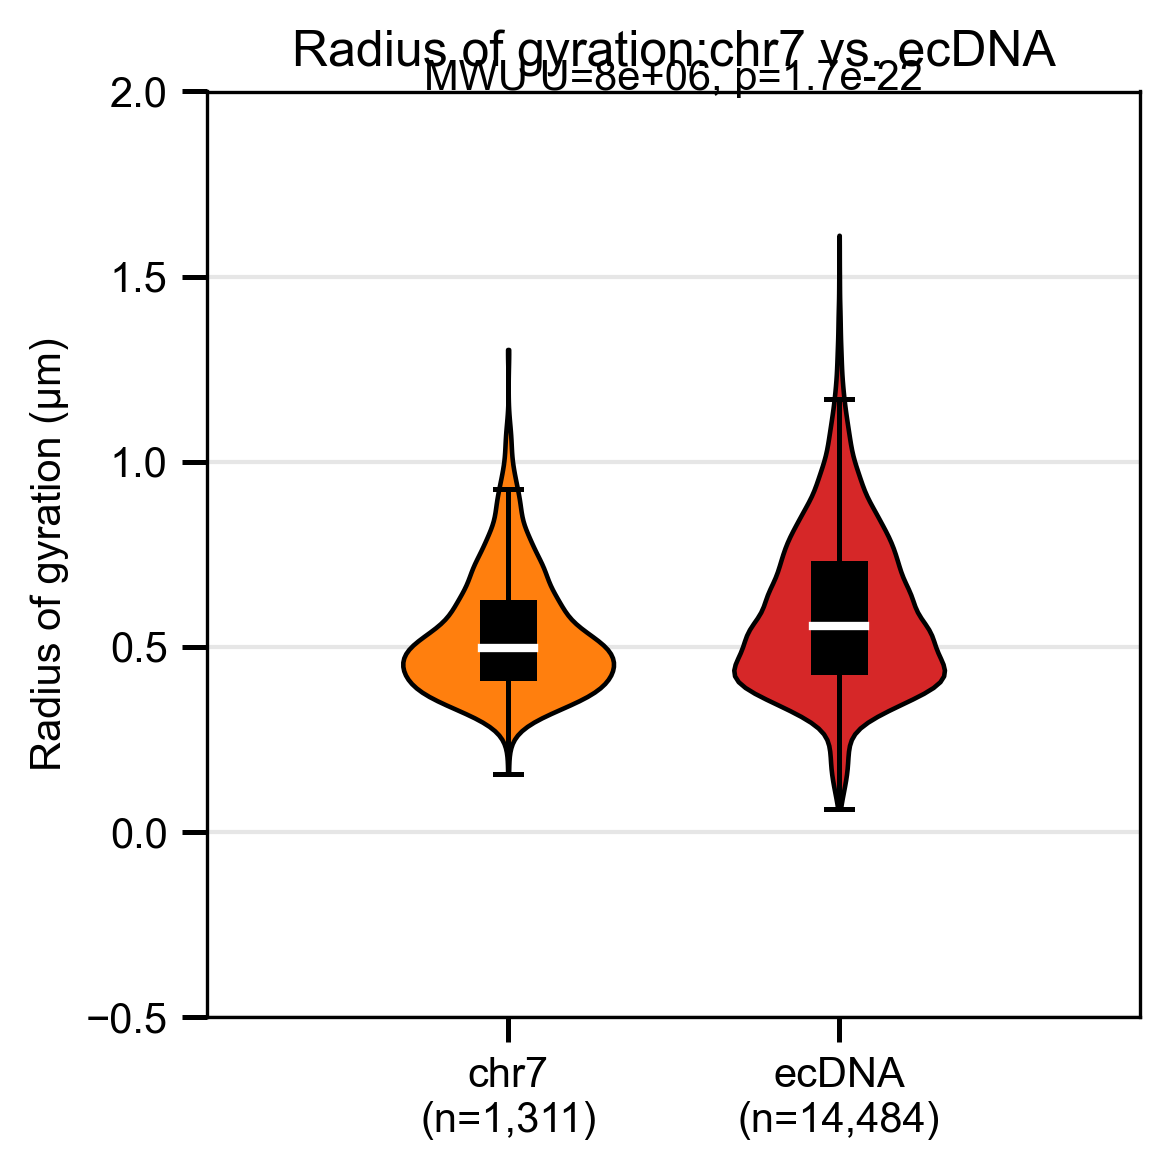

In [54]:
violin_two_groups_by_bool_mean_matplotlib(
    df=df_plot_violin,
    val_col='rgs',
    bool_col="is_circular",  # your boolean column
    order = (False, True),
    group_labels={True: "ecDNA", False: "chr7"},
    colors=("C1", "C3"),
    title="Radius of gyration:chr7 vs. ecDNA",
    y_label='Radius of gyration (µm)',
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative="two-sided", # "two-sided", "less"
    y_tick_step= 0.5,
    stats_fontsize=10,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=2,
)

# intron analysis

The genomic regions imaged on the ecDNA contains only 3 genes: EGFR, EGFR-AS1, LANCL2

## trace colocalization

- identify the bright spots from each imaging round
- colocalize it with the traces
- bursting ones are passed a further brightness threshold

In [ ]:
chr7_iQs = [20, 22, 26]

In [ ]:
chr7_introns= ['EGFR-AS1_introns',
 'EGFR_introns',
 'LANCL2_introns']

In [ ]:
dic_iQ_to_gene = dict(zip(chr7_iQs, chr7_introns))

In [ ]:
## brightness cutoff to be considered introns
dic_thh = {}
for iQ in tqdm(chr7_iQs):
    dic_thh[iQ] = 5

In [ ]:
intron_analysis_folder = r'D:\GBM39\ecDNATracer\intronQ_analysis__Human_P4CC_EGFR_12_17_2024\anchor_points-iQ'
save_tbl_fld = r'D:\GBM39\ecDNATracer\intronQ_analysis__Human_P4CC_EGFR_12_17_2024\bursting_tbl_iQ'
pix_size = [0.5, 0.108333, 0.108333]
os.makedirs(save_tbl_fld, exist_ok=True)
for iQ in tqdm(chr7_iQs):
    tbl_iQ = run_single_gene_intron_colocalization(iQ, dic_thh,
                                            linear_traces, circ_traces)
    tbl_iQ.to_csv(os.path.join(save_tbl_fld, f'iQ{iQ}__{dic_iQ_to_gene[iQ]}__bursting_tbl_linked.csv'))

## build summary dataframe

In [ ]:
XF = np.load(r'D:\GBM39\ecDNATracer\fulldata__Q_Human_P4CC_EGFR_12_17_2024\Conv_zscan2__264_colorflip_chromabb--XF.npz')['XF']
XF.shape

In [ ]:
# Per-color statistics (colors 0/1/2):
medianH_C, uCols = get_medianH_for_XF(XF, subsample=50, seed=0, group_by="col")

In [ ]:
## load in the colors for iQ
dic_hyb_color = np.load('C:/GBM39/design/FFBBRNA_48color-dic_hyb_color.pkl', allow_pickle = True)

In [ ]:
save_tbl_fld = r'D:\GBM39\ecDNATracer\intronQ_analysis__Human_P4CC_EGFR_12_17_2024\bursting_tbl_iQ'
save_iQ_tbl_list = [os.path.join(save_tbl_fld, f'iQ{iQ}__{dic_iQ_to_gene[iQ]}__bursting_tbl_linked.csv') for iQ in chr7_iQs]

In [ ]:
df_summary = build_bursting_binary_matrix_merge_on_global_row_pool(save_iQ_tbl_list,
                                                             uCols, medianH_C, dic_hyb_color, 
                                           th_zscore_dict={0:1, 1:2, 2:2})

# antibody analysis

## compute antibody

In [ ]:
dic_iA_flds = {1: 'A1_H3K9me3_Pol2S2_set1', 2:'A1_H3K9me3_Pol2S2_set1',
              4: 'A2_SC35_H3K27Ac_set1', 5: 'A2_SC35_H3K27Ac_set1',
              7: 'A3_Lam_Nup98-high_set1',8:'A3_Lam_Nup98-high_set1'}
dic_iA_Around = {1:'A1_R1_2_3',2:'A1_R1_2_3',
                4: 'A2_R4_5_6', 5: 'A2_R4_5_6',
                7: 'A3_Lam_Nup98-high', 8: 'A3_Lam_Nup98-high'}
dic_iA_antibody = {1: 'H3K9me3', 2: 'Pol2S2',
                   4: 'SC35', 5: 'H3K27Ac',
                  7: 'LAMA1', 8: 'NUP98'}

dic_iA_antibody_fullname = {1: 'H3K9me3', 2: 'p-RNA polymerase II', 4: 'Spliceosome', 5: 'H3K27Ac', 7: 'Lamina A/C', 8: 'NUP98'}


In [ ]:
uifovs_full = np.unique(np.array(df_summary['cell_id']) // 10**5)
len(uifovs_full)

In [ ]:
## run it for all fovs

df_ab_full = df_summary_full.copy()
for iA in [2, 4,5, 7, 8]:
    iA_save_dir = os.path.join(antibody_save_dir, f'iA{iA}')
    df_plot_full = get_antibody_norm_brightness_zscore_streaming(iA = iA, 
                                                       df_meta = df_ab_full, 
                                                       ufovs = uifovs_full, use_robust_std= True, batch_size_fovs=1,
                                                        save_dir = iA_save_dir)

In [ ]:
pool_to_traces = {"linear": linear_traces, "circular": circ_traces}

def drift_globber_human(iA):
    return glob.glob(os.path.join(
            r"D:\GBM39\Human_P4CC_EGFR_12_17_2024\antibody_analysis", "*drift*"
        ))

def fld_from_iA_human(iA):
    return rf"Y:\RenImaging2\Brett\Human_P4CC_EGFR_12_17_2024\{dic_iA_flds[iA]}"


In [ ]:
## run it for all fovs
df_ab_full = df_summary.copy()
antibody_save_dir = r'D:\GBM39\Human_P4CC_EGFR_12_17_2024\antibody_nodeconv_analysis'

for iA in [2,5,7]: # Pol2S2, H3K27ac, Lamina
    iA_save_dir = os.path.join(antibody_save_dir, f'iA{iA}')
    df_plot_full = get_antibody_norm_brightness_zscore_streaming(
        iA=iA,
        df_meta=df_ab_full,
        ufovs=uifovs_full,
        use_robust_std=True,
        batch_size_fovs=1,
        fov_from_ifov=lambda ifov: f"Conv_zscan2__{str(int(ifov)).zfill(3)}",
        drift_globber=drift_globber_human,
        fld_from_iA=fld_from_iA_human,
        flat_field_tag=r"Y:\apple3\Brett\Human_P4CC_EGFR_12_17_2024\flat_field",
        pool_to_traces=pool_to_traces,
        pix_size=pix_size,
    )

In [ ]:
df_gbm = df_merged[df_merged['cluster'].isin([2,4,5,7])][['cell_id', 'pool', 'trace_id', 'avg_NN_dist', 'global_row',
       'matrix_name', 'EGFR', 'EGFR-AS1', 'LANCL2', 
       'cluster', 'total_genes_transcribed_3genes',
       'rgs_trimmed', 'zone', 'Pol2S2_brightness_z', 'SC35_brightness_z',
       'H3K27Ac_brightness_z', 'LAMA1_brightness_z', 'NUP98_brightness_z']]
df_gbm.shape

In [ ]:
df_acmes_ecDNA = df_gbm[(df_gbm['cluster'].isin([4,5])) & (df_gbm['pool'] == 'circular')]
df_acmes_ecDNA.shape

In [ ]:
df_acmes_ecDNA.to_csv(r'021726_df_traces_rg_introns_antibody-nodeconv-local_cluster45_ecDNAonly__Human_P4CC_EGFR_12_17_2024.csv')

# zone analysis

In [ ]:
adata_ds2 = sc.read_h5ad(r'C:/GBM39/Human_P4CC_EGFR_12_17_2024/20250506_P4_core_dec_set_2.h5ad')

## identify hotspot

Find the cell with the highest copy number and appoint that cell as the 'origin'

In [ ]:
import numpy as np

# Extract relevant Series
copy = adata_ds2.obs['D1_P1F123-counts_nuc_redo2'].astype(float)
fovs = adata_ds2.obs['ifov_redo2']

# Step 1: Compute average copy number per FOV
avg_copy_per_fov = copy.groupby(fovs).mean()

# Step 2: Find the FOV with the highest average
top_fov = avg_copy_per_fov.idxmax()

# Step 3: Get cells in that FOV
cells_in_top_fov = adata_ds2.obs['ifov_redo2'] == top_fov
copy_in_top_fov = copy[cells_in_top_fov]

# Step 4: Find the cell with the highest copy number in that FOV
idx_max = copy_in_top_fov.idxmax()

# Step 5: Get the X_spatial coordinate
hottest_spot_coord = adata_ds2.obsm['X_spatial'][adata_ds2.obs_names.get_loc(idx_max)]

# Output
print(f"FOV with hottest average: {top_fov}")
print(f"Hottest spot coordinate: {hottest_spot_coord}")


In [ ]:
def plot_spatial_values(scdata, value_col, cmap='bwr', transpose=1, flipx=1, flipy=1,
                        smin=5, smax=50, vmin=None, vmax=None, log2=False,
                        hotspot_coord=None, hotspot_size=200, hotspot_color='yellow'):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import matplotlib.cm as cm
    from matplotlib.colors import Normalize

    fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")

    # Spatial coordinates
    coords = scdata.obsm['X_spatial']
    x, y = (coords * [-flipx, -flipy])[:, ::-transpose].T

    values = scdata.obs[value_col]

    if pd.api.types.is_numeric_dtype(values):
        values = values.astype(float).values
        if log2:
            values = np.log2(values + 1)

        norm = Normalize(vmin=vmin if vmin is not None else np.nanmin(values),
                         vmax=vmax if vmax is not None else np.nanmax(values))

        colors = cm.get_cmap(cmap)(norm(values))
        sizes = smin + (smax - smin) * norm(values)

        sc = ax.scatter(x, y, c=colors, s=sizes, marker='.')

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax)
        label = f"log2({value_col}+1)" if log2 else value_col
        cbar.set_label(label, color='white')
        cbar.ax.yaxis.set_tick_params(color='white')
        plt.setp(cbar.ax.get_yticklabels(), color='white')

    else:
        raise ValueError("Value column must be numeric to scale size and color.")

    # Optional: overlay hotspot
    if hotspot_coord is not None:
        hx, hy = (np.array(hotspot_coord) * [-flipx, -flipy])[::-transpose]
        ax.scatter(hx, hy, color=hotspot_color, s=hotspot_size, marker='o', edgecolor='black', linewidth=1.5)

    ax.set_axis_off()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_4896\3642462100.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(values))


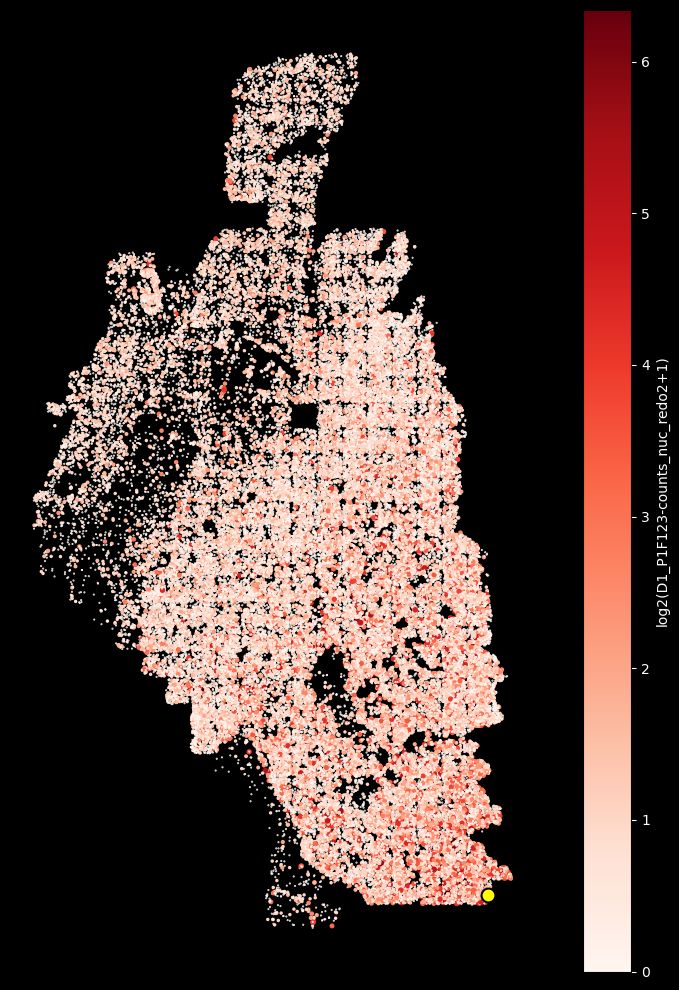

In [110]:
plot_spatial_values(
    adata_ds2,
    value_col='D1_P1F123-counts_nuc_redo2',
    cmap='Reds',       # blue (low) → red (high)
    smin=1, smax=50, log2 = True,    # small to big size scale
    hotspot_coord=hottest_spot_coord, hotspot_size= 100,
)

## assign zone

In [ ]:
def assign_distance_bins(adata, hotspot_coord, n_bins=5, col_prefix='distance_bin'):
    import numpy as np
    import pandas as pd

    coords = adata.obsm['X_spatial']
    dists = np.linalg.norm(coords - np.array(hotspot_coord), axis=1)

    # Force bins to start at 0 exactly
    bin_edges = np.linspace(0, np.nanmax(dists), n_bins + 1)
    distance_bins = pd.cut(dists, bins=bin_edges, include_lowest=True)

    adata.obs[f'{col_prefix}_interval'] = distance_bins.astype(str)
    adata.obs[f'{col_prefix}_int'] = pd.Categorical(distance_bins).codes

    return adata.obs[[f'{col_prefix}_int', f'{col_prefix}_interval']]


In [171]:
def assign_distance_bins(adata, hotspot_coord, n_bins=5, col_prefix='distance_bin'):
    import numpy as np
    import pandas as pd

    coords = adata.obsm['X_spatial']
    dists = np.linalg.norm(coords - np.array(hotspot_coord), axis=1)

    # Force bins to start at 0 exactly
    bin_edges = np.linspace(0, np.nanmax(dists), n_bins + 1)
    distance_bins = pd.cut(dists, bins=bin_edges, include_lowest=True)

    adata.obs[f'{col_prefix}_interval'] = distance_bins.astype(str)
    adata.obs[f'{col_prefix}_int'] = pd.Categorical(distance_bins).codes

    return adata.obs[[f'{col_prefix}_int', f'{col_prefix}_interval']]


In [172]:
label_df = assign_distance_bins(adata_ds2, hottest_spot_coord, n_bins=6)

In [174]:
label_df['distance_bin_int'].value_counts()

distance_bin_int
2    20753
3    15909
1    15529
4     8424
0     8100
5     2750
Name: count, dtype: int64

In [ ]:
def plot_spatial_values_categorical(scdata, cat_col, transpose=1, flipx=1, flipy=1, s=20, cmap='tab20'):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import matplotlib.cm as cm

    fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')

    # Spatial coordinates
    coords = scdata.obsm['X_spatial']
    x, y = (coords * [-flipx, -flipy])[:, ::-transpose].T

    # Extract and clean category column
    cats = scdata.obs[cat_col].astype(str)
    unique_vals = sorted(cats.unique())
    n_colors = len(unique_vals)

    # Assign distinct colors
    colormap = cm.get_cmap(cmap, n_colors)
    color_dict = {val: colormap(i) for i, val in enumerate(unique_vals)}

    # Plot each group
    for val in unique_vals:
        mask = cats == val
        ax.scatter(x[mask], y[mask], c=[color_dict[val]], s=s, label=val, marker='.')

    ax.set_axis_off()
    ax.set_aspect('equal')
    plt.legend(title=cat_col, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()


C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_4896\410670450.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap, n_colors)


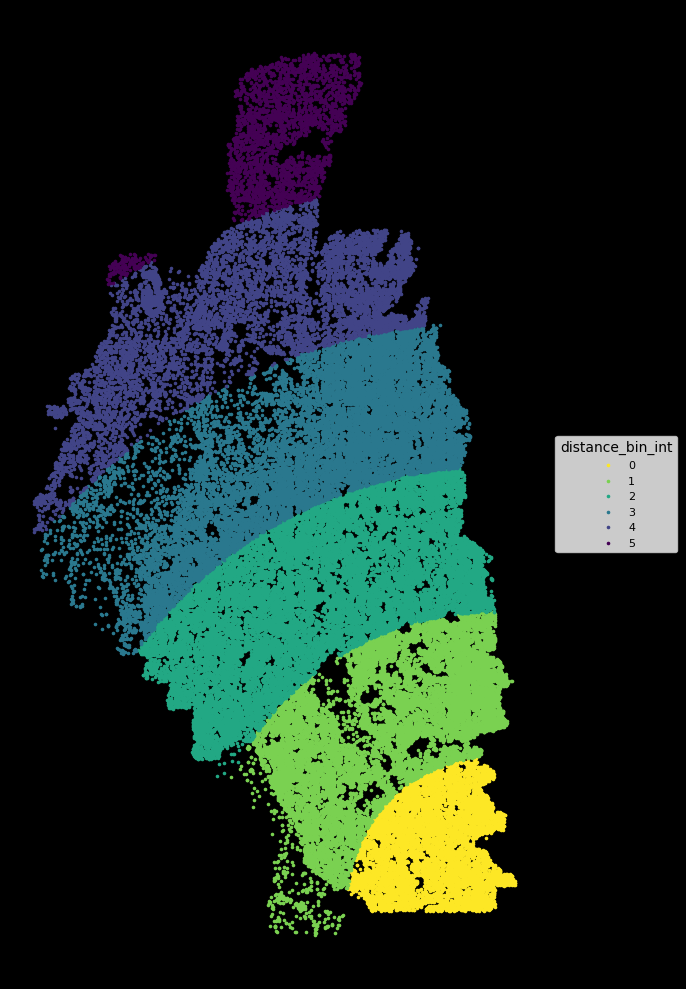

In [176]:
plot_spatial_values_categorical(
    adata_ds2,
    cat_col='distance_bin_int',
    s=10,
    cmap='viridis_r'  # 'tab20', 'Set2', or any matplotlib categorical cmap
)

C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_4896\410670450.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap, n_colors)


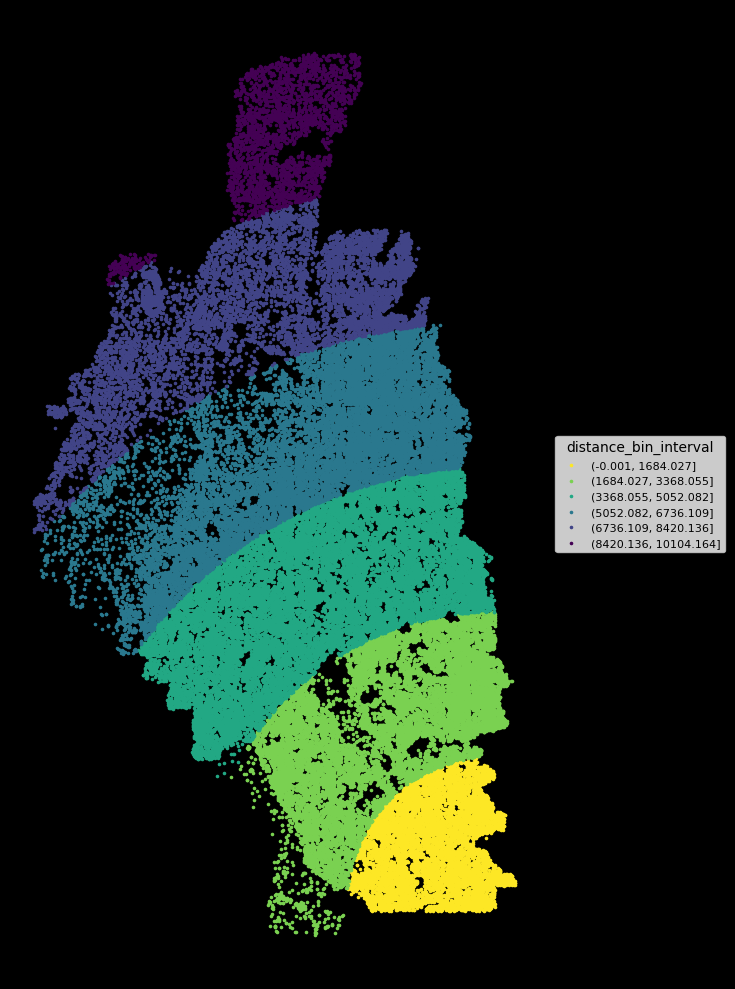

In [177]:
plot_spatial_values_categorical(
    adata_ds2,
    cat_col='distance_bin_interval',
    s=10,
    cmap='viridis_r'  # 'tab20', 'Set2', or any matplotlib categorical cmap
)

## comparing features across zones

In [56]:
df_acmes_ecDNA = pd.read_csv(r'C:/GBM39/Human_P4CC_EGFR_12_17_2024/021726_df_traces_rg_introns_antibody-nodeconv-local_cluster45_ecDNAonly__Human_P4CC_EGFR_12_17_2024.csv',
                            index_col = 0)
df_acmes_ecDNA

,cell_id,pool,trace_id,avg_NN_dist,global_row,matrix_name,EGFR,EGFR-AS1,LANCL2,cluster,total_genes_transcribed_3genes,rgs_trimmed,zone,Pol2S2_brightness_z,SC35_brightness_z,H3K27Ac_brightness_z,LAMA1_brightness_z,NUP98_brightness_z
4,78,circular,0,3.683765,29922,circular,1,1,0,5.0,2,0.569076,2.0,-0.133037,-4.082469,-0.271157,0.626512,4.429602
5,78,circular,1,2.517885,29923,circular,1,1,0,5.0,2,0.737715,2.0,4.596643,-1.344602,2.061787,0.239521,3.204622
6,78,circular,2,1.615319,29924,circular,1,1,1,5.0,3,0.627595,2.0,1.074195,-0.387145,0.298738,-0.161320,0.740612
7,78,circular,3,2.514414,29925,circular,1,0,1,5.0,2,0.419278,2.0,1.313005,-1.891034,0.202270,2.444462,3.130395
8,78,circular,4,2.709279,29926,circular,1,1,1,5.0,3,0.455607,2.0,-0.911904,-1.552320,-0.679957,4.447150,5.963666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36151,43000350,circular,11,1.658578,27095,circular,1,1,1,4.0,3,0.363460,1.0,-0.058480,-0.357224,1.791320,0.157305,-0.753768
36152,43000350,circular,12,1.206830,27096,circular,1,1,0,4.0,2,0.812848,1.0,-0.298598,-0.087559,0.097812,0.766690,1.380192
36153,43000350,circular,13,1.340750,27097,circular,1,1,0,4.0,2,0.654699,1.0,0.824734,0.235657,0.171748,0.451603,-0.232631
36160,43000484,circular,0,3.070579,27106,circular,0,0,1,4.0,1,0.345890,1.0,-0.768721,-0.246762,-0.256000,-0.297081,0.661019


In [67]:
df_acmes_ecDNA['zone_1indexed'] = df_acmes_ecDNA['zone'] + 1

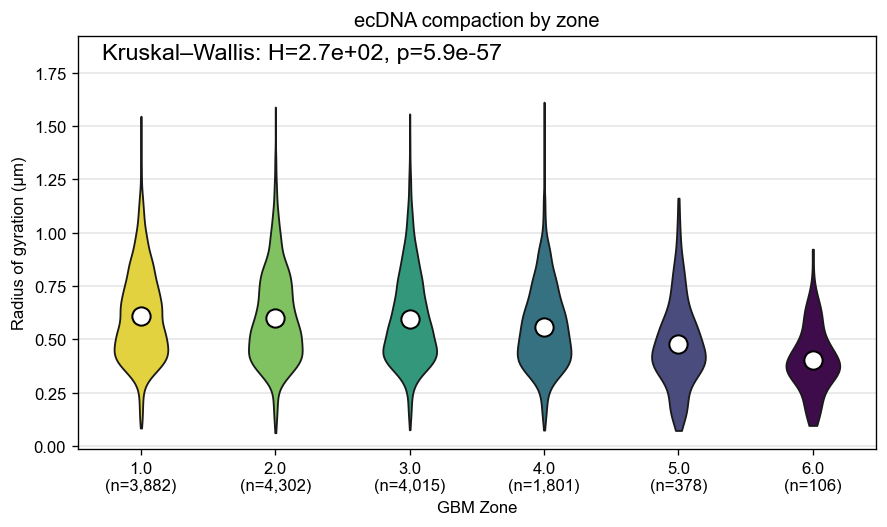

In [68]:
_ = seaborn_multi_violin_from_df(
    df_acmes_ecDNA,
    value_col="rgs_trimmed",
    group_col="zone_1indexed",
    test="kruskal",
    colors = plt.cm.viridis_r(np.linspace(0, 1, 6)),
    do_posthoc=True,
    x_label = 'GBM Zone',
    y_label="Radius of gyration (µm)",
    title="ecDNA compaction by zone",
    figsize=(7.5, 4.5),
    # save_svg = f'C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/zone_single_var/ACMES_ecDNA_Rg_by_zone.svg'
)


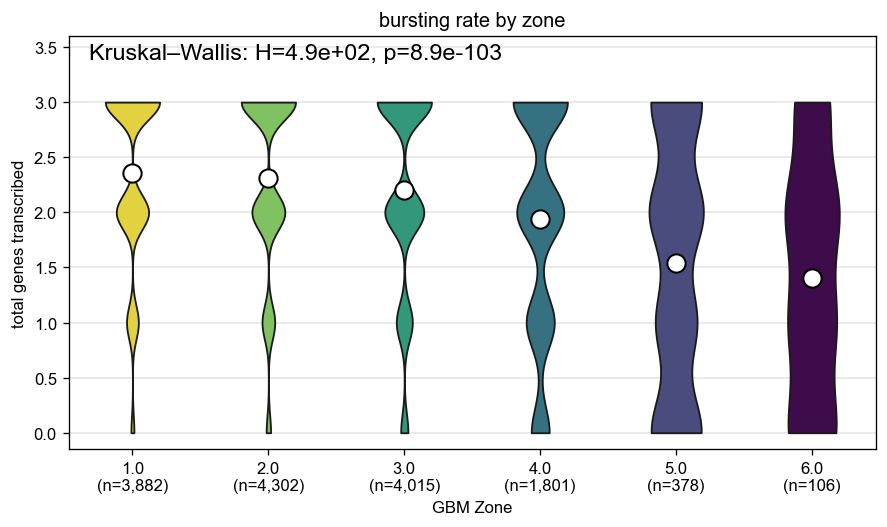

In [69]:
_ = seaborn_multi_violin_from_df(
    df_acmes_ecDNA,
    value_col="total_genes_transcribed_3genes",
    group_col="zone_1indexed",
    test="kruskal",
    colors = plt.cm.viridis_r(np.linspace(0, 1, 6)),
    do_posthoc=True,
    x_label = 'GBM Zone',
    y_label="total genes transcribed",
    title="bursting rate by zone",
    figsize=(7.5, 4.5),
    # save_svg = f'C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/zone_single_var/ACMES_ecDNA_bursting_by_zone.svg'
)


## multi-way relationship between the zone

Rg, transcription, antibody and zone

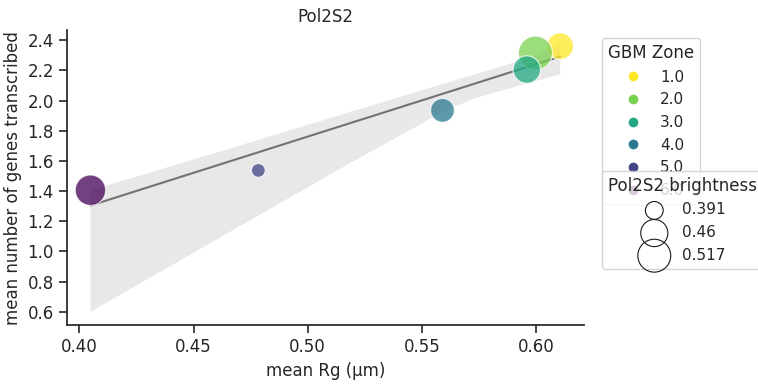

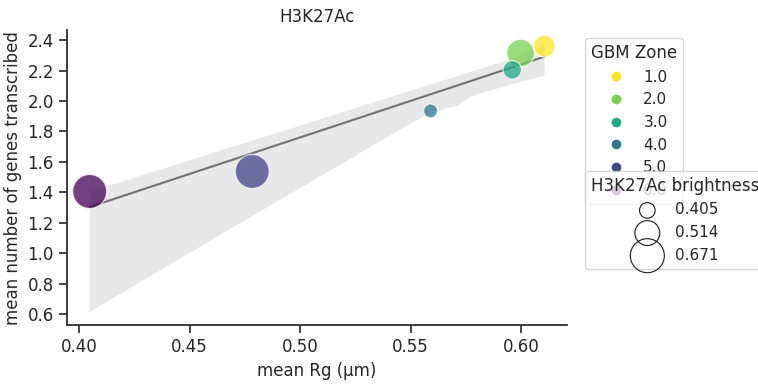

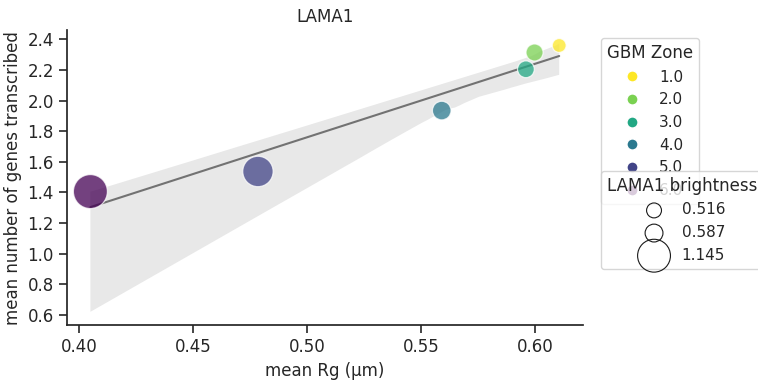

In [74]:
for ab in ['Pol2S2', 'H3K27Ac', 'LAMA1']:
    plot_group_mean_scatter_with_size(
        df_acmes_ecDNA,
        xcol="rgs_trimmed",
        ycol="total_genes_transcribed_3genes",
        zcol="zone_1indexed",
        size_col=f"{ab}_brightness_z",
        size_stat="mean",
        s_min=100,
        s_max=600,
        cmap_name="viridis_r",
        add_reg_line=True,
        rasterize_scatter=False,
        # save_svg=None,
        figsize=(10, 4),
        add_pearson=False,

        # labels
        x_label='mean Rg (µm)',
        y_label='mean number of genes transcribed',
        z_label='GBM Zone',
        group_label=f'{ab} brightness',
        title = f'{ab}',
        # save_svg = rf'C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/zone_4waycorr/nodeconv-local_{ab}_ACMES_ecDNA_zone_4waycorr.svg'
    )

## 3 way: Rg, transcription, and zone

In [75]:
df_acmes_ecDNA["pct_genes_transcribed_3genes"] = df_acmes_ecDNA["total_genes_transcribed_3genes"] / 3

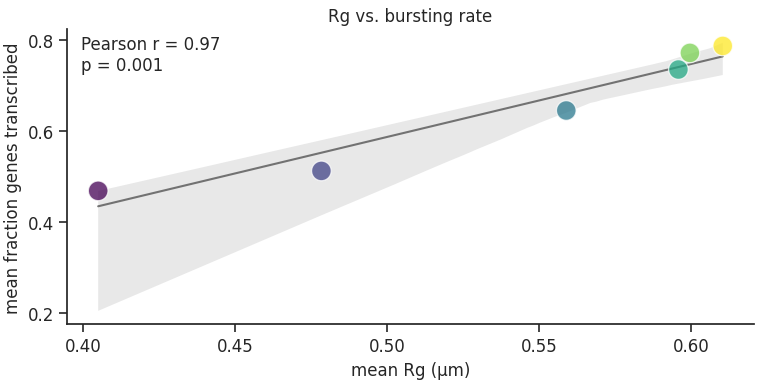

In [77]:
for ab in ['Pol2S2']:
    plot_group_mean_scatter_with_size(
        df_acmes_ecDNA,
        xcol="rgs_trimmed",
        ycol="pct_genes_transcribed_3genes",
        zcol="zone_1indexed",
        size_col=None,
        size_stat="mean",
        # s_min=100,
        s_max=300,
        cmap_name="viridis_r",
        add_reg_line=True,
        rasterize_scatter=False,
        # save_svg=None,
        figsize=(10, 4),
        add_pearson=True,

        # labels
        x_label='mean Rg (µm)',
        y_label='mean fraction genes transcribed',
        z_label='GBM Zone',
        group_label=f'{ab} brightness',
        title = 'Rg vs. bursting rate',
        # save_svg = rf'C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/zone_4waycorr/nodeconv-local_ACMES_ecDNA_zone_4waycorr.svg'
    )

# comparing features across transcriprional states

In [57]:
df_acmes_ecDNA["bursting_group"] = np.where(df_acmes_ecDNA['total_genes_transcribed_3genes'] <= 0, "OFF",
                  "ON")

In [59]:
df_plot = df_acmes_ecDNA[df_acmes_ecDNA["bursting_group"].isin(['ON', 'OFF'])]

In [60]:
df_plot['is_ON'] = df_plot['bursting_group'] == 'ON'

In [62]:
# fig, axes = plt.subplots(4, 2, figsize=(10, 8), dpi=200, sharex=True)

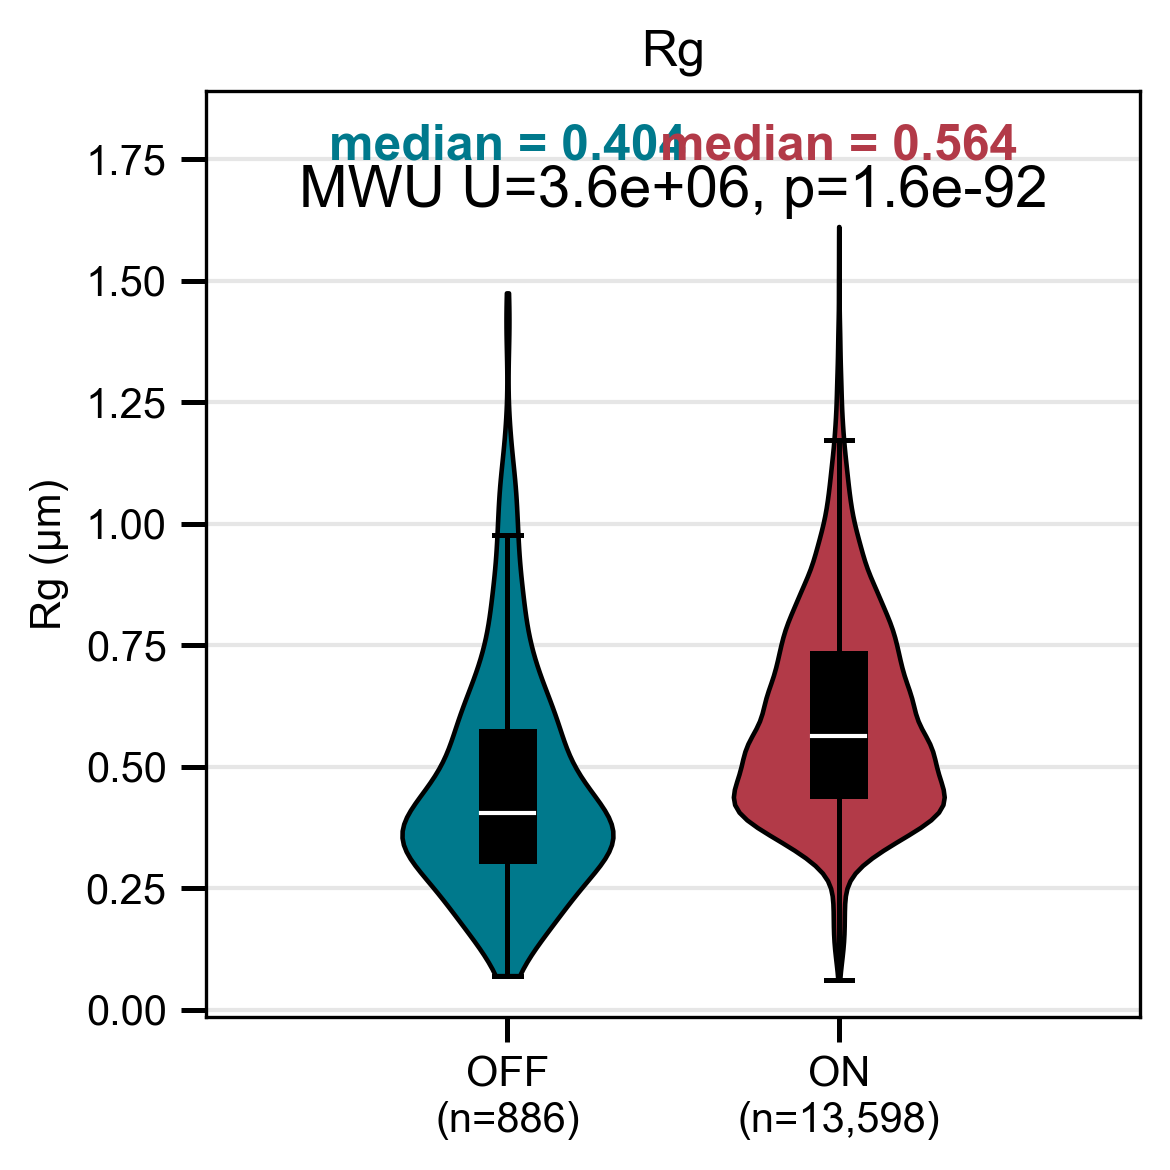

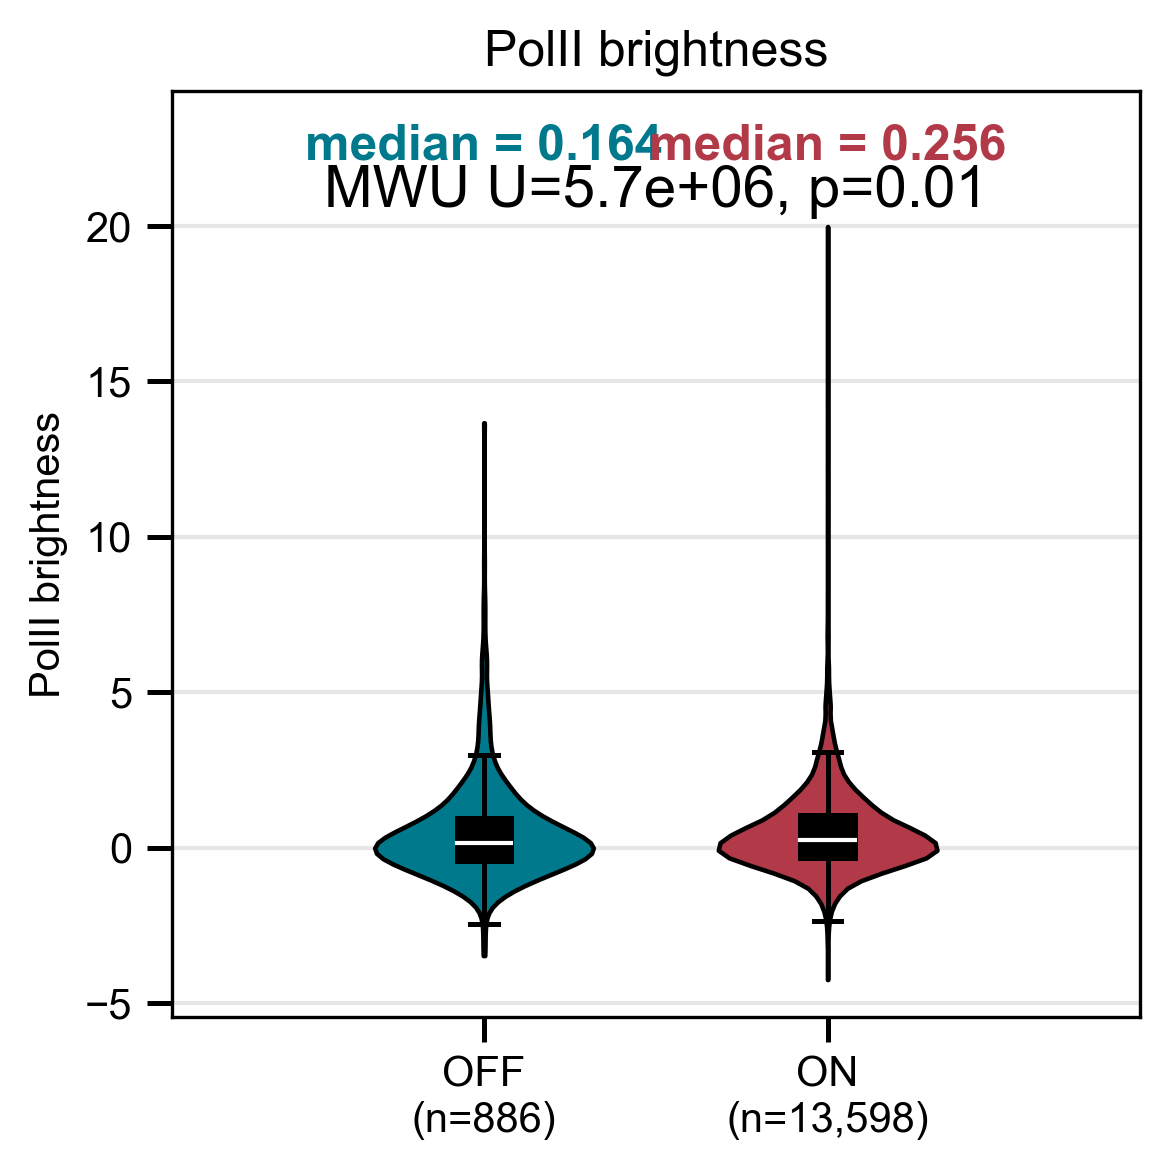

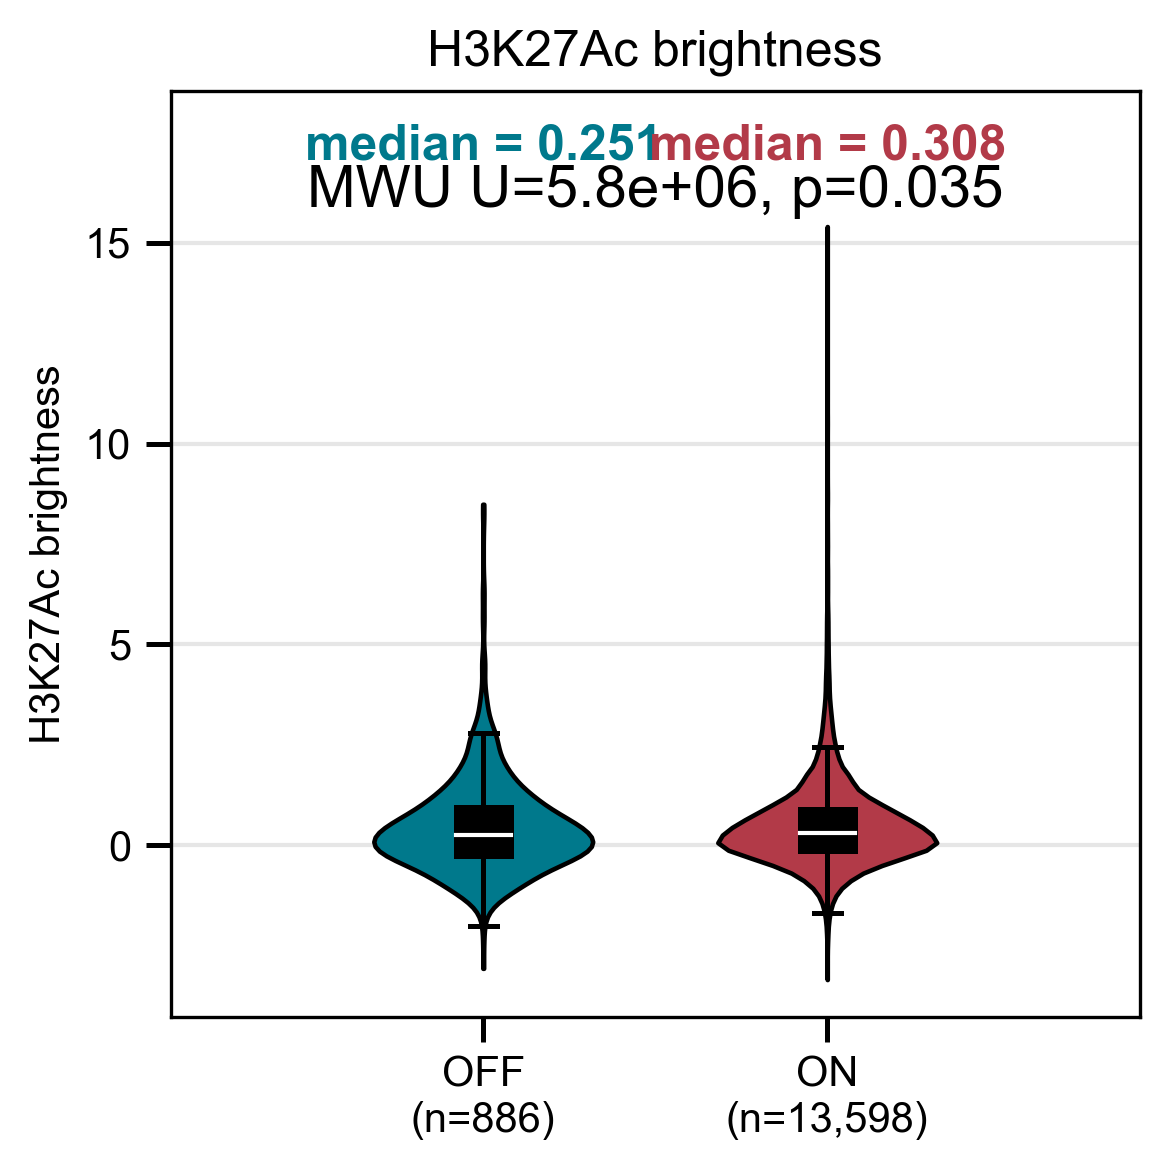

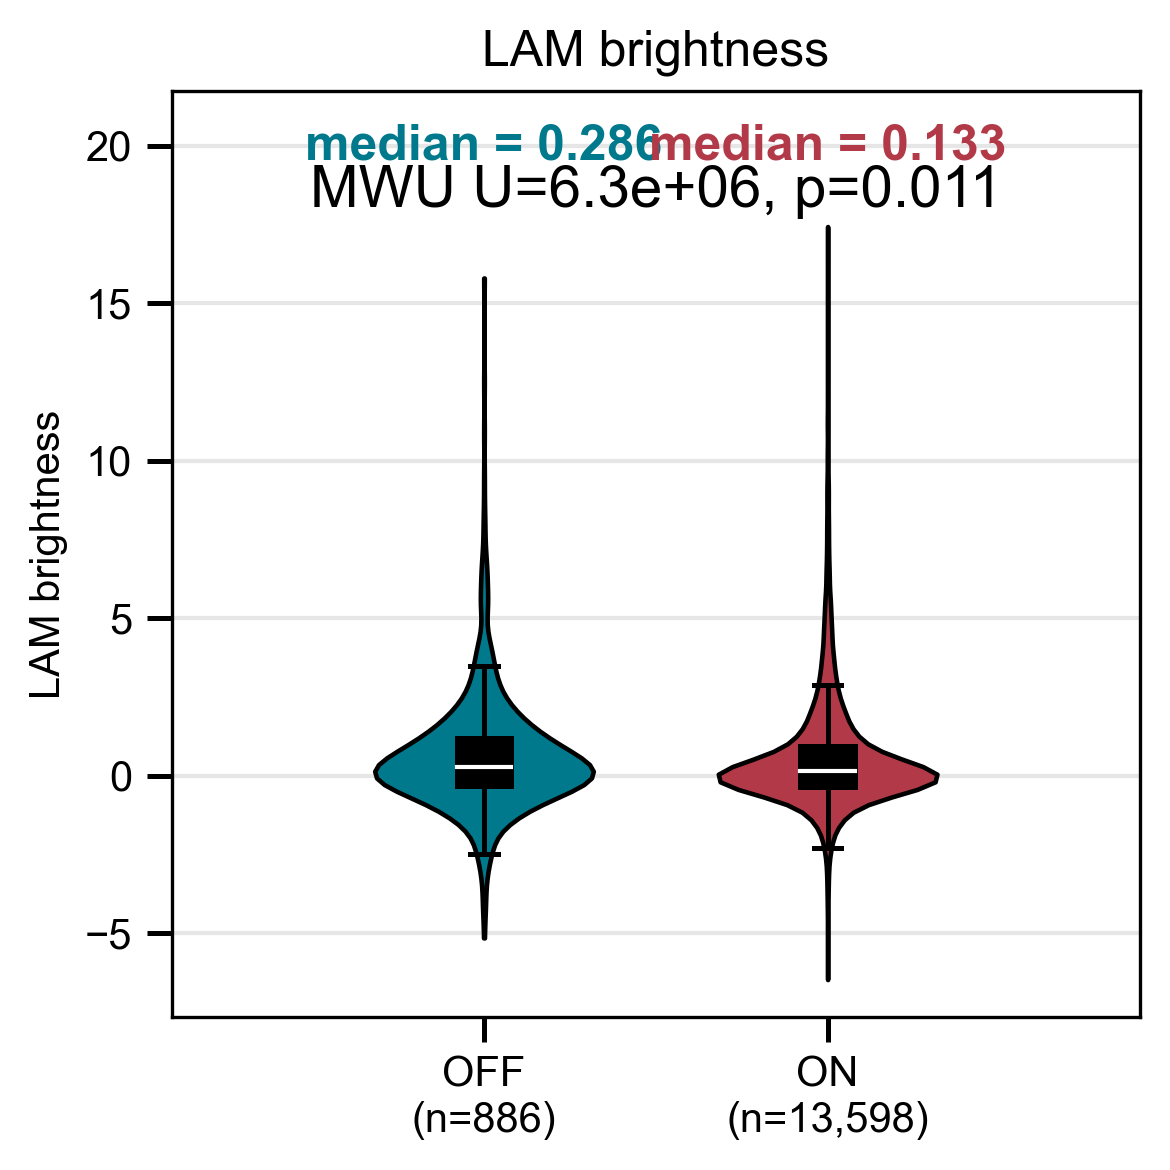

In [63]:
val_cols = [
    'rgs_trimmed', 
    "Pol2S2_brightness_z",
    "H3K27Ac_brightness_z",
    'LAMA1_brightness_z', 
    
]

titles = [
    'Rg',
    "PolII brightness",
    "H3K27Ac brightness",
    "LAM brightness"
]

for ax, val_col, title in zip(axes.ravel(), val_cols, titles):
    if title == 'Rg':
        ylabel = 'Rg (µm)'
    elif title =='bursting rate':
        ylabel = '% genes transcribed'
    else:
        ylabel = title
    
    if val_col == 'LAMA1_brightness_z':
        mwu_alt = 'greater'
    else:
        mwu_alt = 'less'
    violin_two_groups_by_bool_median_matplotlib(
    df=df_plot,
    val_col=val_col,
    bool_col="is_ON",  # your boolean column
    order = (False, True),
    group_labels={True: "ON", False: "OFF"},
    colors=("#00798C", "#B23A48"),
    title=title,
    y_label=ylabel,
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative=mwu_alt, # "two-sided", "less"
    stats_fontsize=14,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=1,
    transform=None,
    annotate_median=True,
    median_fmt="{:.3f}",
    median_text_size = 12,
    # save_svg= f'C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/bursting_on_off_antibody/ecDNA_{title}__bursting_ON_OFF_violins.svg'
)